In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [29]:
svs = pd.read_csv('../../data/leopard_cohort/leopard_consensus_sv_class_annotated.tsv', sep='\t')
svs['tissue_type'] = 'Whole Blood:Whole Blood'
# filter out SVs with span < 1000
is_inter = svs.chr1 != svs.chr2
keep = is_inter | (svs.span >= 1000)
svs = svs[keep].copy()
print("Total SVs: ", len(svs))
svs.head()

Total SVs:  1859


,chr1,pos1,chr2,pos2,span,ref,alt1,alt2,svtype,sample,control_AD,control_DP,tumor_AD,tumor_DP,participant,sample_type,tissue_type
2,1,46679031,2,160123001,-1,A,]2:160123001]A,G[1:46679031[,TRA,18138-001BL,0,20,12,56,18138-001,BL,Whole Blood:Whole Blood
3,1,89475928,1,89478625,2697,C,C[1:89478625[,]1:89475928]A,DEL,18138-001BL,0,47,13,65,18138-001,BL,Whole Blood:Whole Blood
4,1,109494858,3,110413394,-1,T,]3:110413394]T,C[1:109494858[,TRA,18138-001BL,0,15,30,20,18138-001,BL,Whole Blood:Whole Blood
5,1,109495133,3,110413395,-1,G,G[3:110413395[,]1:109495133]A,TRA,18138-001BL,0,15,9,19,18138-001,BL,Whole Blood:Whole Blood
6,1,109846791,7,24591125,-1,A,A[7:24591125[,]1:109846791]G,TRA,18138-001BL,0,24,10,21,18138-001,BL,Whole Blood:Whole Blood


In [30]:
# add SVs from additional ctDNA samples and available matched tumor samples
svs_additions = pd.read_csv('../../data/leopard_cohort/consensus_sv_class_annotated_additions.tsv', sep='\t')
svs_additions.rename(columns={'sample_type': 'tissue_type'}, inplace=True)
svs_additions['control_DP'] = np.nan
svs_additions['control_AD'] = np.nan
svs_additions["sample_type"] = svs_additions.apply(
    lambda r: r["sample"].replace(r["participant"] + "-", "").replace(r["participant"], ""),
    axis=1
)

print("Total Additional SVs: ", len(svs_additions))
# reorder columns
svs_additions = svs_additions[['chr1', 'pos1', 'chr2', 'pos2', 'span', 'ref', 'alt1', 'alt2', 'svtype', 'sample', 'control_AD', 'control_DP', 'tumor_AD', 'tumor_DP', 'participant', 'sample_type', 'tissue_type']]
# merge with existing SVs
svs = pd.concat([svs, svs_additions], ignore_index=True)
print("Total Combined SVs: ", len(svs))
svs.head()


Total Additional SVs:  3019
Total Combined SVs:  4878


,chr1,pos1,chr2,pos2,span,ref,alt1,alt2,svtype,sample,control_AD,control_DP,tumor_AD,tumor_DP,participant,sample_type,tissue_type
0,1,46679031,2,160123001,-1,A,]2:160123001]A,G[1:46679031[,TRA,18138-001BL,0.0,20.0,12,56,18138-001,BL,Whole Blood:Whole Blood
1,1,89475928,1,89478625,2697,C,C[1:89478625[,]1:89475928]A,DEL,18138-001BL,0.0,47.0,13,65,18138-001,BL,Whole Blood:Whole Blood
2,1,109494858,3,110413394,-1,T,]3:110413394]T,C[1:109494858[,TRA,18138-001BL,0.0,15.0,30,20,18138-001,BL,Whole Blood:Whole Blood
3,1,109495133,3,110413395,-1,G,G[3:110413395[,]1:109495133]A,TRA,18138-001BL,0.0,15.0,9,19,18138-001,BL,Whole Blood:Whole Blood
4,1,109846791,7,24591125,-1,A,A[7:24591125[,]1:109846791]G,TRA,18138-001BL,0.0,24.0,10,21,18138-001,BL,Whole Blood:Whole Blood


In [31]:
svs['participant'].unique()

array(['18138-001', '18138-004', '18138-010', '18138-011', '18138-015',
       '18138-023', '18138-028', '18138-033', '18138-039', '18138-043',
       '18138-044', '18138-054', '18138-064', '18138-072', '18138-081',
       '18138-093', '18138-094', '18138-098', '18138-100', '18138-101',
       '18138-117'], dtype=object)

In [32]:
svs['sample'].unique()

array(['18138-001BL', '18138-004BL', '18138-004PD1', '18138-010BL',
       '18138-011BL', '18138-015BL', '18138-023BL', '18138-023PD2',
       '18138-028BL', '18138-033BL', '18138-039BL', '18138-039PD',
       '18138-043BL', '18138-044BL', '18138-054BL', '18138-064BL',
       '18138-072BL', '18138-072PR', '18138-081BL', '18138-093BL',
       '18138-094BL', '18138-098BL', '18138-100BL', '18138-101BL',
       '18138-117BL', '18138-010C1', '18138-072C1', '18138-072C2',
       '18138-100C2', '18138-023M18', '18138-004-F', '18138-039DX-F',
       '18138-072DX-F', '18138-094-F', '18138-098-F', '18138-100-DX-F',
       '18138-117DX-F'], dtype=object)

In [33]:
# remove exact duplicates (by chr1, pos1, chr2, pos2, span, svtype)
svs = svs.drop_duplicates(subset=['chr1', 'pos1', 'chr2', 'pos2', 'span', 'svtype', 'sample'])
svs.to_csv('../../data/leopard_cohort/leopard_consensus_sv_class_annotated_combined.tsv', sep='\t', index=False)
print(len(svs))

4878


In [34]:
# create BED file of filtered SVs (keep chr, start, end, SV ID) for convertion to hg38 coordinates (gnomAD current version uses hg38)
# Add a unique SV index
svs['sv_index'] = range(len(svs))

# Create breakpoint 1 entries (chr1, pos1)
bp1 = pd.DataFrame({
    'chrom': 'chr' + svs['chr1'].astype(str),
    'start': svs['pos1'] - 1,
    'end': svs['pos1'],
    'name': 'SV' + svs['sv_index'].astype(str) + '_BP1_' + svs['sample']
})

# Create breakpoint 2 entries (chr2, pos2)
bp2 = pd.DataFrame({
    'chrom': 'chr' + svs['chr2'].astype(str),
    'start': svs['pos2'] - 1,
    'end': svs['pos2'],
    'name': 'SV' + svs['sv_index'].astype(str) + '_BP2_' + svs['sample']
})

breakpoints_bed = pd.concat([bp1, bp2], ignore_index=True)
breakpoints_bed = breakpoints_bed.sort_values(['chrom', 'start'])

print(f"Total SVs: {len(svs)}")
print(f"Total breakpoints: {len(breakpoints_bed)}")
print(breakpoints_bed.head(10))

# Save as BED (w/ no header for liftOver)
breakpoints_bed.to_csv('../../data/leopard_cohort/sv_breakpoints_pre_liftover.bed', sep='\t', index=False, header=False)

Total SVs: 4878
Total breakpoints: 9756
     chrom    start      end                      name
149   chr1   756259   756260    SV149_BP1_18138-004PD1
150   chr1   756259   756260    SV150_BP1_18138-004PD1
5028  chr1   758138   758139    SV150_BP2_18138-004PD1
4558  chr1  1530205  1530206  SV4558_BP1_18138-117DX-F
9436  chr1  1531730  1531731  SV4558_BP2_18138-117DX-F
436   chr1  2627227  2627228     SV436_BP1_18138-015BL
5314  chr1  2631284  2631285     SV436_BP2_18138-015BL
3878  chr1  3097435  3097436    SV3878_BP1_18138-004-F
8756  chr1  3098563  3098564    SV3878_BP2_18138-004-F
1002  chr1  6366193  6366194    SV1002_BP1_18138-072BL


In [35]:
# Load the lifted BED file (https://genome.ucsc.edu/cgi-bin/hgLiftOver)
lifted = pd.read_csv('../../data/leopard_cohort/hglft_genome_29e453_a501d0.bed', sep='\t', header=None, names=['chrom', 'start', 'end', 'name', 'fragment'])

# Parse the name column: {SVindex}_BP{1or2}_{sample}
lifted['sv_index'] = lifted['name'].str.extract(r'SV(\d+)_')[0].astype(int)
lifted['breakpoint'] = lifted['name'].str.extract(r'_BP(\d)_')[0].astype(int)
lifted['sample'] = lifted['name'].str.replace(r'SV\d+_BP\d_', '', regex=True)

# Convert to 1-based position (BED is 0-based, add 1 to start)
lifted['pos'] = lifted['end']

print(f"Total lifted breakpoints: {len(lifted)}")

# Separate BP1 and BP2
bp1 = lifted[lifted['breakpoint'] == 1][['sv_index', 'sample', 'chrom', 'pos']].copy()
bp1.columns = ['sv_index', 'sample', 'chr1', 'pos1']

bp2 = lifted[lifted['breakpoint'] == 2][['sv_index', 'sample', 'chrom', 'pos']].copy()
bp2.columns = ['sv_index', 'sample', 'chr2', 'pos2']

# Merge to reconstruct SVs
reconstructed = pd.merge(bp1, bp2, on=['sv_index', 'sample'], how='outer', indicator=True)

# Identify complete SVs (both breakpoints lifted)
complete_svs = reconstructed[reconstructed['_merge'] == 'both'].drop(columns='_merge')

# Identify SVs with missing partner
bp1_only = reconstructed[reconstructed['_merge'] == 'left_only'][['sv_index', 'sample', 'chr1', 'pos1']]
bp2_only = reconstructed[reconstructed['_merge'] == 'right_only'][['sv_index', 'sample', 'chr2', 'pos2']]

print(f"Complete SVs (both breakpoints lifted): {len(complete_svs)}")
print(f"SVs with only BP1 lifted (BP2 failed): {len(bp1_only)}")
print(f"SVs with only BP2 lifted (BP1 failed): {len(bp2_only)}")

complete_svs['chr1'] = complete_svs['chr1'].str.replace('chr', '')
complete_svs['chr2'] = complete_svs['chr2'].str.replace('chr', '')
complete_svs['pos1'] = complete_svs['pos1'].astype(int)
complete_svs['pos2'] = complete_svs['pos2'].astype(int)

complete_svs = complete_svs[['chr1', 'pos1', 'chr2', 'pos2', 'sample', 'sv_index']]

print(complete_svs.head(10))

# Save complete SVs
complete_svs.to_csv('../../data/leopard_cohort/consensus_sv_hg38.csv', sep='\t', index=False)

Total lifted breakpoints: 9732
Complete SVs (both breakpoints lifted): 4864
SVs with only BP1 lifted (BP2 failed): 1
SVs with only BP2 lifted (BP1 failed): 3
  chr1       pos1 chr2       pos2       sample  sv_index
0    1   46213359    2  159266490  18138-001BL         0
1    1   89010245    1   89012942  18138-001BL         1
2    1  108952236    3  110694547  18138-001BL         2
3    1  108952511    3  110694548  18138-001BL         3
4    1  109304169    7   24551506  18138-001BL         4
5    1  153700671    1  153721395  18138-001BL         5
6    2   41746062   12     425301  18138-001BL         6
7    2   81527641    2   81539734  18138-001BL         7
8    2   85245341    2   85385852  18138-001BL         8
9    2   89813046    2   89819110  18138-001BL         9


In [36]:
# add back svtype to the hg38-converted SVs
sv_lookup = svs[['sv_index', 'svtype', 'participant']].drop_duplicates('sv_index') #hg19
complete_svs = complete_svs.merge(sv_lookup, on='sv_index', how='left')
print(complete_svs)

     chr1       pos1 chr2       pos2         sample  sv_index svtype  \
0       1   46213359    2  159266490    18138-001BL         0    TRA   
1       1   89010245    1   89012942    18138-001BL         1    DEL   
2       1  108952236    3  110694547    18138-001BL         2    TRA   
3       1  108952511    3  110694548    18138-001BL         3    TRA   
4       1  109304169    7   24551506    18138-001BL         4    TRA   
...   ...        ...  ...        ...            ...       ...    ...   
4859    X    7705841    X    7705842  18138-117DX-F      4873    DEL   
4860    X   32642692    X   33176687  18138-117DX-F      4874    INV   
4861    X   42653038    X   42654619  18138-117DX-F      4875    DEL   
4862    X  135385762    X  135388368  18138-117DX-F      4876    DEL   
4863    X  148428177    X  148429717  18138-117DX-F      4877    DEL   

     participant  
0      18138-001  
1      18138-001  
2      18138-001  
3      18138-001  
4      18138-001  
...          ...  
48

In [37]:
# find how many participants have the same exact SVs
sv_counts = complete_svs.groupby(['chr1', 'pos1', 'chr2', 'pos2', 'svtype']).agg({
    'participant': 'nunique',
}).reset_index()

sv_counts.columns = ['chr1', 'pos1', 'chr2', 'pos2', 'svtype', 'n_participants']

# Filter to SVs found in more than 1 participant
recurrent_svs = sv_counts[sv_counts['n_participants'] > 1].copy()
#recurrent_svs.to_csv('../data/recurrent_svs.csv', index=False)

print(f"Total unique SVs: {len(sv_counts) - len(recurrent_svs)}")
print(f"SVs found in >1 participants: {len(recurrent_svs)}")

recurrent_svs = recurrent_svs.sort_values('n_participants', ascending=False)
recurrent_svs.head()

Total unique SVs: 2249
SVs found in >1 participants: 616


,chr1,pos1,chr2,pos2,svtype,n_participants
596,13,39360062,13,39361344,DEL,17
1164,2,89815309,2,89817769,DEL,15
2303,7,70961199,7,70973894,INV,13
809,16,85155108,16,85156196,INV,13
643,14,46648665,14,62759566,INV,12


In [38]:
# annotate the recurrent SVs
key = ['chr1', 'pos1', 'chr2', 'pos2', 'svtype']

recurrent_lookup = (recurrent_svs[key + ['n_participants']].drop_duplicates(subset=key))

complete_svs = complete_svs.merge(recurrent_lookup, on=key, how='left')
complete_svs['recurrent'] = complete_svs['n_participants'].notna().astype(int)
complete_svs['n_participants'] = complete_svs['n_participants'].fillna(1).astype(int)
complete_svs = complete_svs.rename(columns={'n_participants': 'n_participants_recurrent'})

complete_svs

,chr1,pos1,chr2,pos2,sample,sv_index,svtype,participant,n_participants_recurrent,recurrent
0,1,46213359,2,159266490,18138-001BL,0,TRA,18138-001,1,0
1,1,89010245,1,89012942,18138-001BL,1,DEL,18138-001,1,0
2,1,108952236,3,110694547,18138-001BL,2,TRA,18138-001,9,1
3,1,108952511,3,110694548,18138-001BL,3,TRA,18138-001,7,1
4,1,109304169,7,24551506,18138-001BL,4,TRA,18138-001,2,1
...,...,...,...,...,...,...,...,...,...,...
4859,X,7705841,X,7705842,18138-117DX-F,4873,DEL,18138-117,4,1
4860,X,32642692,X,33176687,18138-117DX-F,4874,INV,18138-117,1,0
4861,X,42653038,X,42654619,18138-117DX-F,4875,DEL,18138-117,2,1
4862,X,135385762,X,135388368,18138-117DX-F,4876,DEL,18138-117,1,0


In [40]:
chr_order = {str(i): i for i in range(1, 23)}
chr_order.update({"X": 23, "Y": 24})

def canonize(df):
    r1 = df['chr1'].map(chr_order)
    r2 = df['chr2'].map(chr_order)
    swap = (r2 < r1) | ((r2 == r1) & (df['pos2'] < df['pos1']))

    tmp_chr = df.loc[swap, 'chr1'].copy()
    tmp_pos = df.loc[swap, 'pos1'].copy()

    df.loc[swap, 'chr1'] = df.loc[swap, 'chr2'].values
    df.loc[swap, 'pos1'] = df.loc[swap, 'pos2'].values
    df.loc[swap, 'chr2'] = tmp_chr.values
    df.loc[swap, 'pos2'] = tmp_pos.values

    print("Rows swapped: ", swap.sum())
    print(df.loc[swap].head(5))

    return df

gnomad_file = '../../data/gnomad.v4.1.sv.sites.bed.gz'

gnomad = pd.read_csv(gnomad_file, sep='\t', compression='gzip', usecols=['#chrom', 'start', 'end', 'CHR2', 'END2', 'AF'])

# Filter gnomAD to AF > 0.1 (common variants)
gnomad = gnomad[gnomad['AF'] > 0.1].copy()
print(f"gnomAD SVs with AF > 0.1: {len(gnomad)}")

gnomad['chr1'] = gnomad['#chrom'].astype(str).str.replace('chr', '')
gnomad['chr2'] = gnomad['CHR2'].astype(str).str.replace('chr', '')
gnomad['pos1'] = gnomad['start']
gnomad['pos2'] = np.where(gnomad['END2'].notna(), gnomad['END2'], gnomad['end'])

gnomad['pos1'] = gnomad['pos1'].astype(int)
gnomad['pos2'] = gnomad['pos2'].astype(int)

gnomad = canonize(gnomad)

def find_gnomad_match(row, gnomad_df, slop=15):
    # Filter gnomAD to same chromosomes
    candidates = gnomad_df[
        (gnomad_df['chr1'] == str(row['chr1'])) & 
        (gnomad_df['chr2'] == str(row['chr2']))
    ]
    
    if len(candidates) == 0:
        return False, None
    
    # Check if both breakpoints are within slop
    bp1_match = (abs(candidates['pos1'] - row['pos1']) <= slop)
    bp2_match = (abs(candidates['pos2'] - row['pos2']) <= slop)
    
    matches = candidates[bp1_match & bp2_match]
    
    if len(matches) > 0:
        best_match = matches.loc[matches['AF'].idxmax()]
        match_info = (best_match['chr1'], best_match['pos1'], 
                      best_match['chr2'], best_match['pos2'], 
                      best_match['AF'])
        return True, match_info
    return False, None


print("\nFinding gnomAD matches...")
matches = []
match_details = []
# might change this logic based on breakpoint precision for SvABA / choosing a % of span for buffer instead of fixed value
slop = 15

complete_svs = canonize(complete_svs)

for i, (idx, row) in enumerate(complete_svs.iterrows()):
    is_match, info = find_gnomad_match(row, gnomad, slop)
    matches.append(is_match)
    match_details.append(info)

complete_svs['gnomad_match'] = matches
complete_svs['gnomad_details'] = match_details  # Tuple: (chr1, pos1, chr2, pos2, AF)

matched = complete_svs['gnomad_match'].sum()
print(f"Total SVs: {len(complete_svs)}")
print(f"SVs matching gnomAD (AF > 0.1, within {slop}bp): {matched} ({matched/len(complete_svs)*100:.2f}%)")
print(complete_svs[complete_svs['gnomad_match']][['chr1', 'pos1', 'chr2', 'pos2', 'sample', 'gnomad_details']].head(10))

complete_svs.to_csv('../../data/leopard_cohort/consensus_sv_hg38_filtering_criteria.csv', index=False)
complete_svs.head()

gnomAD SVs with AF > 0.1: 123463
Rows swapped:  0
Empty DataFrame
Columns: [#chrom, start, end, CHR2, END2, AF, chr1, chr2, pos1, pos2]
Index: []

Finding gnomAD matches...
Rows swapped:  23
    chr1       pos1 chr2       pos2        sample  sv_index   svtype  \
63    21   10684424   21   10687363   18138-001BL        63      DEL   
227   21   10751955   21   10755919  18138-004PD1       227      DEL   
356    9   42791494    9   42793335   18138-010BL       356      DEL   
414   10   41882809   10   41884071   18138-011BL       414      DEL   
439    1  145659207    1  149014213   18138-015BL       439  DUP/INS   

    participant  n_participants_recurrent  recurrent  
63    18138-001                         2          1  
227   18138-004                         1          0  
356   18138-010                         1          0  
414   18138-011                         1          0  
439   18138-015                         1          0  
Total SVs: 4864
SVs matching gnomAD (AF > 0.1,

,chr1,pos1,chr2,pos2,sample,sv_index,svtype,participant,n_participants_recurrent,recurrent,gnomad_match,gnomad_details
0,1,46213359,2,159266490,18138-001BL,0,TRA,18138-001,1,0,False,None
1,1,89010245,1,89012942,18138-001BL,1,DEL,18138-001,1,0,False,None
2,1,108952236,3,110694547,18138-001BL,2,TRA,18138-001,9,1,False,None
3,1,108952511,3,110694548,18138-001BL,3,TRA,18138-001,7,1,False,None
4,1,109304169,7,24551506,18138-001BL,4,TRA,18138-001,2,1,False,None


In [42]:
# find samples that are both recurrent and gnomad matched
to_filter = complete_svs[
    (complete_svs['n_participants_recurrent'] > 2) | (complete_svs['gnomad_match'] == True)
]
print("Number of SVs that are recurrent (>2 participants) and/or gnomad matched:", len(to_filter))
# how many of these are unique SVs?
unique_svs = to_filter[['chr1', 'pos1', 'chr2', 'pos2', 'svtype']].drop_duplicates()
print("Number of unique SVs to filter:", len(unique_svs))
print(to_filter.head())

# filter out the SVs that are in to_filter
# remove the recurrent SVs
key = ['chr1', 'pos1', 'chr2', 'pos2', 'svtype']

svs_filtered = complete_svs.merge(
    to_filter[key],
    on=key,
    how='left',
    indicator=True
).query("_merge == 'left_only'").drop(columns=["_merge"])

print(f"Filtered SV rows: {len(svs_filtered)}")
svs_filtered.to_csv('../../data/leopard_cohort/final_consensus_sv_hg38_filtered.csv', index=False)

# create another filtered version of the SVs with NONE recurrent
svs_filtered_recurrent = complete_svs[complete_svs['recurrent'] != 1].copy()
print(f"Filtered SV rows after removing all recurrent SVs: {len(svs_filtered_recurrent)}")
svs_filtered_recurrent.to_csv('../../data/leopard_cohort/final_consensus_sv_hg38_all_recurrent_filtered.csv', index=False)

Number of SVs that are recurrent (>2 participants) and/or gnomad matched: 2092
Number of unique SVs to filter: 658
   chr1       pos1 chr2       pos2       sample  sv_index   svtype  \
2     1  108952236    3  110694547  18138-001BL         2      TRA   
3     1  108952511    3  110694548  18138-001BL         3      TRA   
9     2   89813046    2   89819110  18138-001BL         9  DUP/INS   
10    2   89815309    2   89817769  18138-001BL        10      DEL   
16    3  143402917    9   95697579  18138-001BL        16      TRA   

   participant  n_participants_recurrent  recurrent  gnomad_match  \
2    18138-001                         9          1         False   
3    18138-001                         7          1         False   
9    18138-001                         8          1         False   
10   18138-001                        15          1         False   
16   18138-001                         4          1          True   

                                    gnomad_detail

In [43]:
svs = svs_filtered.copy()
# prepare clustered SV input
def norm_chr(s):
    s = s.astype(str).str.replace("^chr", "", regex=True)
    return s.replace({"X": "23", "Y": "24"})

svs["chrom1"] = norm_chr(svs["chr1"])
svs["chrom2"] = norm_chr(svs["chr2"])

bedpe = pd.DataFrame({
    "chrom1": svs["chrom1"],
    "start1": svs["pos1"].astype(int) - 1,
    "end1":   svs["pos1"].astype(int),
    "chrom2": svs["chrom2"],
    "start2": svs["pos2"].astype(int) - 1,
    "end2":   svs["pos2"].astype(int),
    "sample": svs["sample"],
    "svclass": svs["svtype"],
})

svclass_map = {
    "TRA": "translocation",
    "DEL": "deletion",
    "DUP/INS": "tandem-duplication",
    "INV": "inversion",
}
bedpe["svclass"] = bedpe["svclass"].map(svclass_map)
print("missing svclass:", bedpe["svclass"].isna().sum())
bedpe.to_csv("../../data/leopard_cohort/clustered_sv_input.bedpe", sep="\t", index=False)

missing svclass: 0


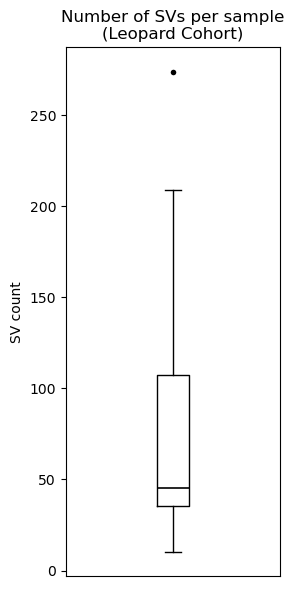

count     30.000000
mean      71.900000
std       64.136358
min       10.000000
25%       35.500000
50%       45.500000
75%      107.250000
max      274.000000
Name: count, dtype: float64

In [4]:
# Visualize the number of SVs per sample 
import matplotlib.pyplot as plt

svs = pd.read_csv('../../data/leopard_cohort/final_consensus_sv_hg38_filtered.csv')

# remove tumor samples (has -F in sample name)
svs = svs[~svs['sample'].str.contains('-F')]
sv_counts = svs['sample'].value_counts()

plt.figure(figsize=(3, 6))
plt.boxplot(
    sv_counts.values,
    vert=True,
    medianprops=dict(color='black', linewidth=1.2, linestyle='-'),  # black median line
    flierprops=dict(  # outlier style
        marker='o',
        markerfacecolor='black',
        markeredgecolor='none',   # no outline
        markersize=4,
        linestyle='none',
        alpha=1
    )
)

plt.title('Number of SVs per sample\n(Leopard Cohort)')
plt.xticks([])
plt.ylabel('SV count')
plt.tight_layout()
plt.show()

sv_counts.describe()